## Logistic Regression 
- Binomial Logistic Regression: (0/1, Yes/No)
- Multinomial Logistic Regressio: (cat, dog, or sheep)
- Ordinal Logistic Regression: (Low, Medium, and High)

In [10]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from sklearn.decomposition import TruncatedSVD
from statsmodels.miscmodels.ordinal_model import OrderedModel

In [11]:
df = pd.read_csv("Data/news_dataset.csv")

df.head()


,title,text,subject,date,label
0,WATCH: Trump Just Told All The Anti-Gay Bigot...,A whole lot of evangelical Trump voters just d...,News,"November 13, 2016",0
1,"China backs U.N. call for justice in Yemen, U....",GENEVA (Reuters) - China signaled on Wednesday...,worldnews,"September 13, 2017",1
2,THE PEOPLE’S PRESIDENT: Trump Meets With Coal ...,,politics,"Feb 16, 2017",0
3,WSJ REPORTER RIPS INTO DEM CANDIDATES For Thei...,THE WSJ S MARY KISSEL NAILS IT ON THE DEM DEBA...,politics,"Nov 15, 2015",0
4,Lawmakers aim to delay U.S. ceding control of ...,WASHINGTON (Reuters) - Critics of a plan for t...,politicsNews,"September 13, 2016",1


In [12]:
df.shape

(6000, 5)

In [13]:
df.columns

Index(['title', 'text', 'subject', 'date', 'label'], dtype='object')

In [14]:
df["content"] = (
    df["title"].fillna("") + " " +
    df["text"].fillna("")
)

df["content"] = (
    df["content"]
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

print(df[["title", "content", "label"]].head())

                                               title  \
0   WATCH: Trump Just Told All The Anti-Gay Bigot...   
1  China backs U.N. call for justice in Yemen, U....   
2  THE PEOPLE’S PRESIDENT: Trump Meets With Coal ...   
3  WSJ REPORTER RIPS INTO DEM CANDIDATES For Thei...   
4  Lawmakers aim to delay U.S. ceding control of ...   

                                             content  label  
0  WATCH: Trump Just Told All The Anti-Gay Bigots...      0  
1  China backs U.N. call for justice in Yemen, U....      1  
2  THE PEOPLE’S PRESIDENT: Trump Meets With Coal ...      0  
3  WSJ REPORTER RIPS INTO DEM CANDIDATES For Thei...      0  
4  Lawmakers aim to delay U.S. ceding control of ...      1  


In [15]:
vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=30000,
    ngram_range=(1, 2),
    min_df=2
)

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    df["content"],
    df["label"],
    test_size=0.20,
    random_state=42,
    stratify=df["label"]
)

In [17]:
tfidf_binary = TfidfVectorizer(
    stop_words="english",
    max_features=30000,
    ngram_range=(1, 2),
    min_df=2
)

X_train_tfidf = tfidf_binary.fit_transform(X_train)
X_test_tfidf = tfidf_binary.transform(X_test)

print("Training shape:", X_train_tfidf.shape)
print("Testing shape:", X_test_tfidf.shape)

Training shape: (4800, 30000)
Testing shape: (1200, 30000)


In [18]:
binary_model = LogisticRegression(
    max_iter=2000
)

binary_model.fit(
    X_train_tfidf,
    y_train
)

LogisticRegression(max_iter=2000)

In [19]:
y_pred_binary = binary_model.predict(X_test_tfidf)

In [20]:
accuracy_binary = accuracy_score(
    y_test,
    y_pred_binary
)

print(
    f"Binomial Logistic Regression Accuracy: "
    f"{accuracy_binary * 100:.2f}%"
)

Binomial Logistic Regression Accuracy: 97.33%


In [21]:
print(
    classification_report(
        y_test,
        y_pred_binary
    )
)

              precision    recall  f1-score   support

           0       0.98      0.97      0.97       600
           1       0.97      0.98      0.97       600

    accuracy                           0.97      1200
   macro avg       0.97      0.97      0.97      1200
weighted avg       0.97      0.97      0.97      1200



In [22]:
cm_binary = confusion_matrix(
    y_test,
    y_pred_binary
)

print(cm_binary)

[[581  19]
 [ 13 587]]


In [23]:
print(df["subject"].value_counts())

subject
politicsNews       1564
worldnews          1436
News               1175
politics            870
left-news           573
Government News     185
Middle-east         100
US_News              97
Name: count, dtype: int64


In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    df["content"],
    df["subject"],
    test_size=0.20,
    random_state=42,
    stratify=df["subject"]
)

In [25]:
tfidf_multi = TfidfVectorizer(
    stop_words="english",
    max_features=30000,
    ngram_range=(1, 2),
    min_df=2
)

X_train_multi = tfidf_multi.fit_transform(X_train)
X_test_multi = tfidf_multi.transform(X_test)

print(X_train_multi.shape)
print(X_test_multi.shape)

(4800, 30000)
(1200, 30000)


In [26]:
multi_model = LogisticRegression(
    max_iter=3000
)

multi_model.fit(
    X_train_multi,
    y_train
)

LogisticRegression(max_iter=3000)

In [27]:
y_pred_multi = multi_model.predict(
    X_test_multi
)

In [28]:
accuracy_multi = accuracy_score(
    y_test,
    y_pred_multi
)

print(
    f"Multinomial Logistic Regression Accuracy: "
    f"{accuracy_multi * 100:.2f}%"
)

Multinomial Logistic Regression Accuracy: 75.67%


In [29]:
print(
    classification_report(
        y_test,
        y_pred_multi,
        zero_division=0
    )
)

                 precision    recall  f1-score   support

Government News       0.00      0.00      0.00        37
    Middle-east       0.50      0.15      0.23        20
           News       0.86      0.96      0.91       235
        US_News       0.17      0.05      0.08        19
      left-news       0.29      0.12      0.17       115
       politics       0.50      0.61      0.55       174
   politicsNews       0.83      0.91      0.87       313
      worldnews       0.86      0.95      0.90       287

       accuracy                           0.76      1200
      macro avg       0.50      0.47      0.46      1200
   weighted avg       0.70      0.76      0.72      1200



In [30]:
ordinal_df = df.copy()

ordinal_df["year"] = pd.to_datetime(
    ordinal_df["date"],
    errors="coerce"
).dt.year

In [31]:
print(
    ordinal_df["year"].value_counts().sort_index()
)

year
2015.0     47
2016.0    918
2017.0    560
Name: count, dtype: int64


In [32]:
ordinal_df = ordinal_df[
    ordinal_df["year"].isin([2015, 2016, 2017])
].copy()

In [33]:
ordinal_df["level"] = ordinal_df["year"].map({
    2015: "Low",
    2016: "Medium",
    2017: "High"
})

In [34]:
print(
    ordinal_df["level"].value_counts()
)

level
Medium    918
High      560
Low        47
Name: count, dtype: int64


In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    ordinal_df["content"],
    ordinal_df["level"],
    test_size=0.20,
    random_state=42,
    stratify=ordinal_df["level"]
)

In [36]:
tfidf_ordinal = TfidfVectorizer(
    stop_words="english",
    max_features=12000,
    ngram_range=(1, 2),
    min_df=2
)

X_train_ord = tfidf_ordinal.fit_transform(X_train)
X_test_ord = tfidf_ordinal.transform(X_test)

In [37]:
svd = TruncatedSVD(
    n_components=40,
    random_state=42
)

X_train_ord = svd.fit_transform(
    X_train_ord
)

X_test_ord = svd.transform(
    X_test_ord
)

print(X_train_ord.shape)
print(X_test_ord.shape)

(1220, 40)
(305, 40)


In [38]:
order = [
    "Low",
    "Medium",
    "High"
]

In [39]:
y_train_ord = pd.Series(
    pd.Categorical(
        y_train,
        categories=order,
        ordered=True
    ),
    index=y_train.index
)

In [40]:
ordinal_model = OrderedModel(
    y_train_ord,
    X_train_ord,
    distr="logit"
)

In [41]:
ordinal_result = ordinal_model.fit(
    method="bfgs",
    disp=False,
    maxiter=200
)

In [42]:
probabilities = ordinal_result.model.predict(
    ordinal_result.params,
    exog=X_test_ord
)

In [43]:
y_pred_ordinal = np.array(order)[
    probabilities.argmax(axis=1)
]

In [44]:
accuracy_ordinal = accuracy_score(
    y_test,
    y_pred_ordinal
)

print(
    f"Ordinal Logistic Regression Accuracy: "
    f"{accuracy_ordinal * 100:.2f}%"
)

Ordinal Logistic Regression Accuracy: 72.13%


In [45]:
print(
    classification_report(
        y_test,
        y_pred_ordinal,
        zero_division=0
    )
)

              precision    recall  f1-score   support

        High       0.70      0.54      0.61       112
         Low       0.00      0.00      0.00         9
      Medium       0.73      0.86      0.79       184

    accuracy                           0.72       305
   macro avg       0.48      0.47      0.47       305
weighted avg       0.70      0.72      0.70       305



In [46]:
# ============================================================
# LOGISTIC REGRESSION
# BINOMIAL + MULTINOMIAL + ORDINAL
# ============================================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.decomposition import TruncatedSVD

from statsmodels.miscmodels.ordinal_model import OrderedModel


# ============================================================
# 1. LOAD DATA
# ============================================================

df = pd.read_csv("Data/news_dataset.csv")

print("Dataset Shape:", df.shape)
print(df.head())


# ============================================================
# 2. CREATE TEXT FEATURE
# ============================================================

df["content"] = (
    df["title"].fillna("") + " " +
    df["text"].fillna("")
)

df["content"] = (
    df["content"]
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)


# ============================================================
# 3. BINOMIAL LOGISTIC REGRESSION
# Target = label
# Classes = 0, 1
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    df["content"],
    df["label"],
    test_size=0.20,
    random_state=42,
    stratify=df["label"]
)

tfidf_binary = TfidfVectorizer(
    stop_words="english",
    max_features=30000,
    ngram_range=(1, 2),
    min_df=2
)

X_train_bin = tfidf_binary.fit_transform(X_train)
X_test_bin = tfidf_binary.transform(X_test)

binary_model = LogisticRegression(
    max_iter=2000
)

binary_model.fit(
    X_train_bin,
    y_train
)

y_pred_bin = binary_model.predict(
    X_test_bin
)

accuracy_bin = accuracy_score(
    y_test,
    y_pred_bin
)

print("\n================================")
print("BINOMIAL LOGISTIC REGRESSION")
print("================================")

print(
    f"Accuracy: {accuracy_bin * 100:.2f}%"
)

print(
    classification_report(
        y_test,
        y_pred_bin,
        zero_division=0
    )
)


# ============================================================
# 4. MULTINOMIAL LOGISTIC REGRESSION
# Target = subject
# Classes = 8 categories
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    df["content"],
    df["subject"],
    test_size=0.20,
    random_state=42,
    stratify=df["subject"]
)

tfidf_multi = TfidfVectorizer(
    stop_words="english",
    max_features=30000,
    ngram_range=(1, 2),
    min_df=2
)

X_train_multi = tfidf_multi.fit_transform(X_train)
X_test_multi = tfidf_multi.transform(X_test)

multi_model = LogisticRegression(
    max_iter=3000
)

multi_model.fit(
    X_train_multi,
    y_train
)

y_pred_multi = multi_model.predict(
    X_test_multi
)

accuracy_multi = accuracy_score(
    y_test,
    y_pred_multi
)

print("\n================================")
print("MULTINOMIAL LOGISTIC REGRESSION")
print("================================")

print(
    f"Accuracy: {accuracy_multi * 100:.2f}%"
)

print(
    classification_report(
        y_test,
        y_pred_multi,
        zero_division=0
    )
)


# ============================================================
# 5. ORDINAL LOGISTIC REGRESSION
# 2015 = Low
# 2016 = Medium
# 2017 = High
# ============================================================

ordinal_df = df.copy()

ordinal_df["year"] = pd.to_datetime(
    ordinal_df["date"],
    errors="coerce"
).dt.year

ordinal_df = ordinal_df[
    ordinal_df["year"].isin([2015, 2016, 2017])
].copy()

ordinal_df["level"] = ordinal_df["year"].map({
    2015: "Low",
    2016: "Medium",
    2017: "High"
})


# ============================================================
# 6. SPLIT ORDINAL DATA
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    ordinal_df["content"],
    ordinal_df["level"],
    test_size=0.20,
    random_state=42,
    stratify=ordinal_df["level"]
)


# ============================================================
# 7. TF-IDF
# ============================================================

tfidf_ord = TfidfVectorizer(
    stop_words="english",
    max_features=12000,
    ngram_range=(1, 2),
    min_df=2
)

X_train_ord = tfidf_ord.fit_transform(X_train)
X_test_ord = tfidf_ord.transform(X_test)


# ============================================================
# 8. SVD
# ============================================================

svd = TruncatedSVD(
    n_components=40,
    random_state=42
)

X_train_ord = svd.fit_transform(
    X_train_ord
)

X_test_ord = svd.transform(
    X_test_ord
)


# ============================================================
# 9. DEFINE ORDER
# ============================================================

order = [
    "Low",
    "Medium",
    "High"
]

y_train_ord = pd.Series(
    pd.Categorical(
        y_train,
        categories=order,
        ordered=True
    ),
    index=y_train.index
)


# ============================================================
# 10. ORDINAL LOGISTIC REGRESSION
# ============================================================

ordinal_model = OrderedModel(
    y_train_ord,
    X_train_ord,
    distr="logit"
)

ordinal_result = ordinal_model.fit(
    method="bfgs",
    disp=False,
    maxiter=200
)


# ============================================================
# 11. PREDICTION
# ============================================================

probabilities = ordinal_result.model.predict(
    ordinal_result.params,
    exog=X_test_ord
)

y_pred_ord = np.array(order)[
    probabilities.argmax(axis=1)
]


# ============================================================
# 12. EVALUATION
# ============================================================

accuracy_ord = accuracy_score(
    y_test,
    y_pred_ord
)

print("\n================================")
print("ORDINAL LOGISTIC REGRESSION")
print("================================")

print(
    f"Accuracy: {accuracy_ord * 100:.2f}%"
)

print(
    classification_report(
        y_test,
        y_pred_ord,
        zero_division=0
    )
)


# ============================================================
# 13. FINAL COMPARISON
# ============================================================

print("\n================================")
print("FINAL MODEL COMPARISON")
print("================================")

print(
    f"Binomial:    {accuracy_bin * 100:.2f}%"
)

print(
    f"Multinomial: {accuracy_multi * 100:.2f}%"
)

print(
    f"Ordinal:     {accuracy_ord * 100:.2f}%"
)

Dataset Shape: (6000, 5)
                                               title  \
0   WATCH: Trump Just Told All The Anti-Gay Bigot...   
1  China backs U.N. call for justice in Yemen, U....   
2  THE PEOPLE’S PRESIDENT: Trump Meets With Coal ...   
3  WSJ REPORTER RIPS INTO DEM CANDIDATES For Thei...   
4  Lawmakers aim to delay U.S. ceding control of ...   

                                                text       subject  \
0  A whole lot of evangelical Trump voters just d...          News   
1  GENEVA (Reuters) - China signaled on Wednesday...     worldnews   
2                                                         politics   
3  THE WSJ S MARY KISSEL NAILS IT ON THE DEM DEBA...      politics   
4  WASHINGTON (Reuters) - Critics of a plan for t...  politicsNews   

                  date  label  
0    November 13, 2016      0  
1  September 13, 2017       1  
2         Feb 16, 2017      0  
3         Nov 15, 2015      0  
4  September 13, 2016       1  

BINOMIAL LOGISTIC REGRES

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

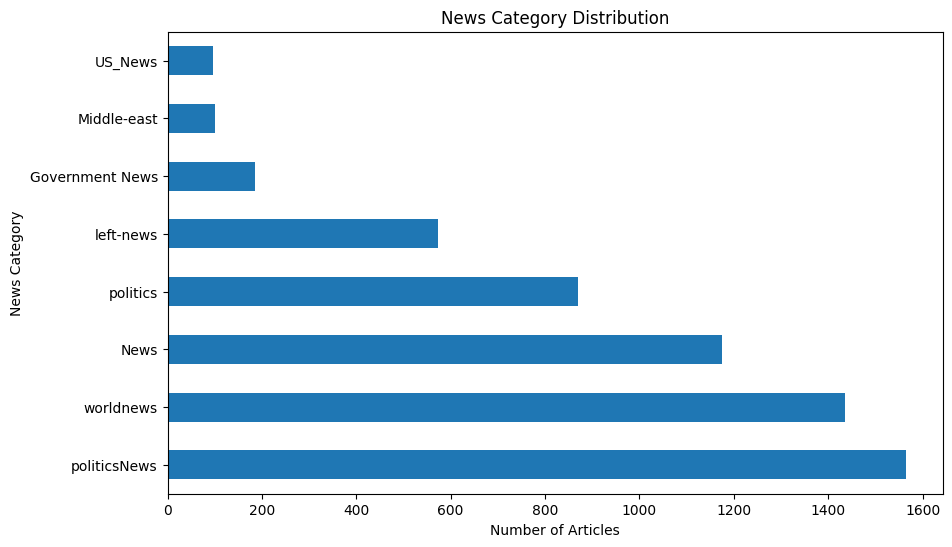

In [48]:
plt.figure(figsize=(10, 6))

df["subject"].value_counts().plot(
    kind="barh"
)

plt.title("News Category Distribution")
plt.xlabel("Number of Articles")
plt.ylabel("News Category")

plt.show()

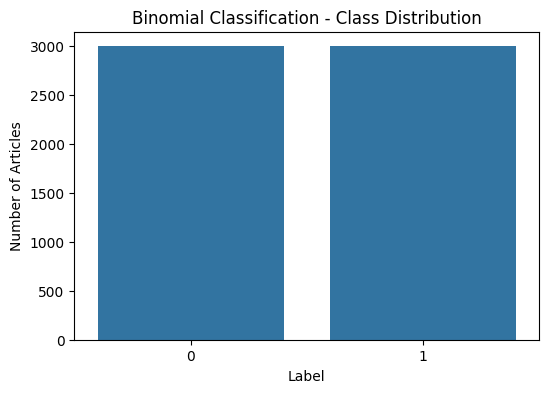

In [50]:
plt.figure(figsize=(6, 4))

sns.countplot(
    x=df["label"]
)

plt.title("Binomial Classification - Class Distribution")
plt.xlabel("Label")
plt.ylabel("Number of Articles")

plt.show()

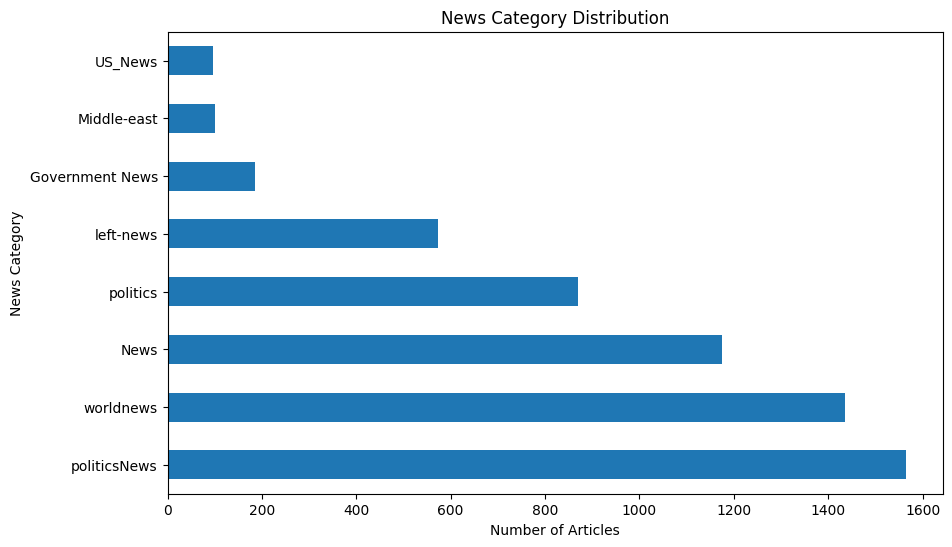

In [51]:
plt.figure(figsize=(10, 6))

df["subject"].value_counts().plot(
    kind="barh"
)

plt.title("News Category Distribution")
plt.xlabel("Number of Articles")
plt.ylabel("News Category")

plt.show()

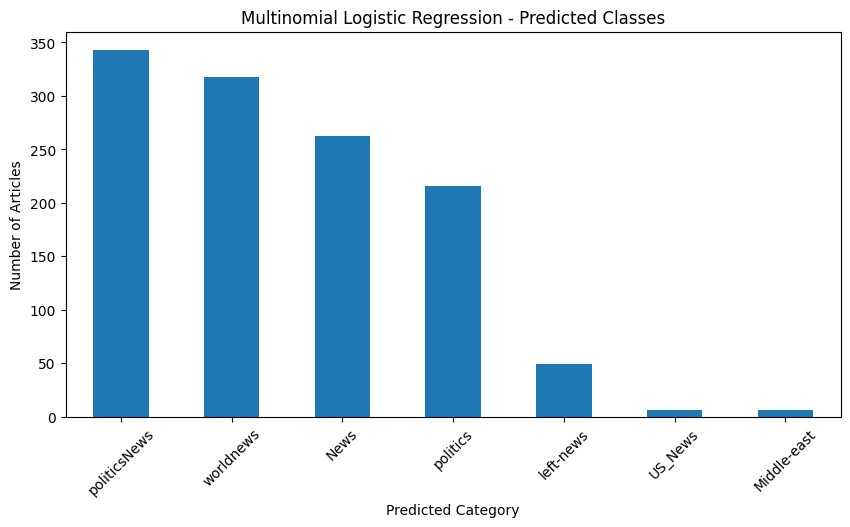

In [53]:
plt.figure(figsize=(10, 5))

pd.Series(y_pred_multi).value_counts().plot(
    kind="bar"
)

plt.title(
    "Multinomial Logistic Regression - Predicted Classes"
)

plt.xlabel("Predicted Category")
plt.ylabel("Number of Articles")

plt.xticks(rotation=45)

plt.show() 

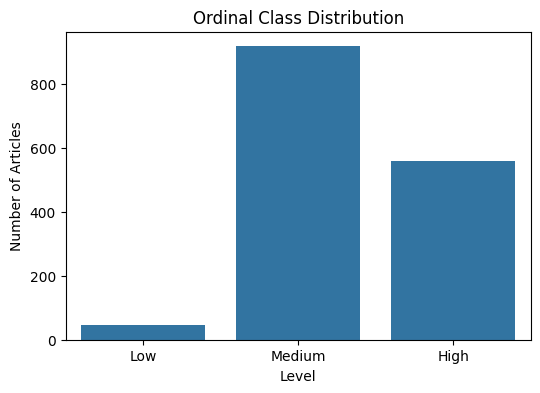

In [54]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=ordinal_df,
    x="level",
    order=["Low", "Medium", "High"]
)

plt.title("Ordinal Class Distribution")
plt.xlabel("Level")
plt.ylabel("Number of Articles")

plt.show()

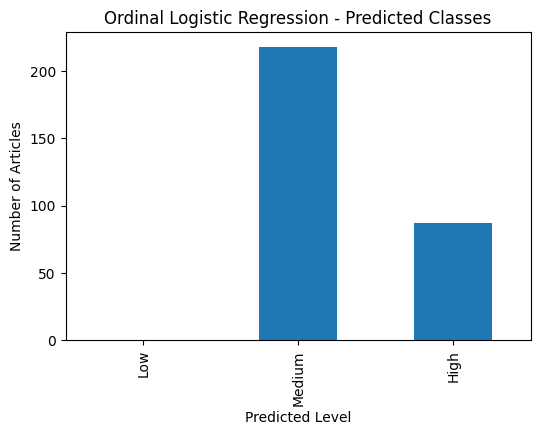

In [56]:
plt.figure(figsize=(6, 4))

pd.Series(y_pred_ordinal).value_counts().reindex(
    ["Low", "Medium", "High"]
).plot(kind="bar")

plt.title(
    "Ordinal Logistic Regression - Predicted Classes"
)

plt.xlabel("Predicted Level")
plt.ylabel("Number of Articles")

plt.show()

In [57]:
results = pd.DataFrame({
    "Model": [
        "Binomial",
        "Multinomial",
        "Ordinal"
    ],
    "Accuracy": [
        accuracy_bin,
        accuracy_multi,
        accuracy_ord
    ]
})

print(results)

         Model  Accuracy
0     Binomial  0.973333
1  Multinomial  0.756667
2      Ordinal  0.721311


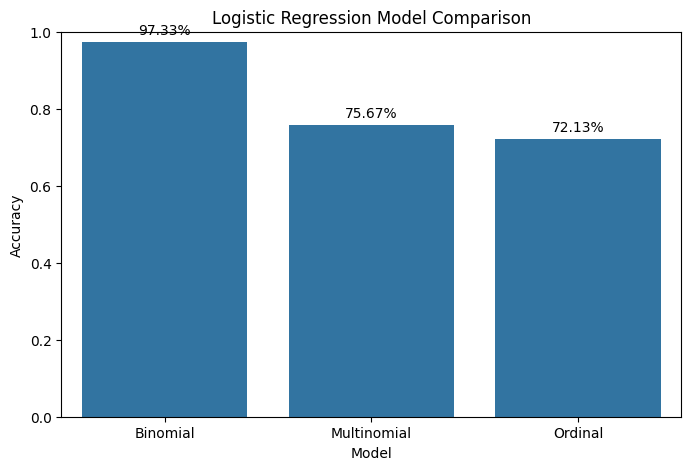

In [58]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=results,
    x="Model",
    y="Accuracy"
)

plt.title(
    "Logistic Regression Model Comparison"
)

plt.xlabel("Model")
plt.ylabel("Accuracy")

plt.ylim(0, 1)

# Add accuracy values
for i, value in enumerate(results["Accuracy"]):
    plt.text(
        i,
        value + 0.02,
        f"{value * 100:.2f}%",
        ha="center"
    )

plt.show()